## Models:

Functions: Input --- Output

Toy manufacturer makes $5 for every toy sold.
f(profit) = x * 5

array([-25, -20, -15, -10,  -5,   0,   5,  10,  15,  20])

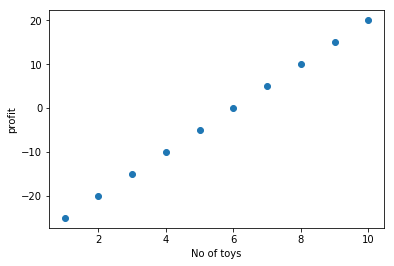

In [515]:
def profit(X):
    return X * 5 - 30 # 5 slope, -30 intercept
X = np.arange(1,11,1) #independent variable
y = profit(X) # dependent variable
plt.scatter(X, y)
plt.ylabel('profit')
plt.xlabel('No of toys')
y

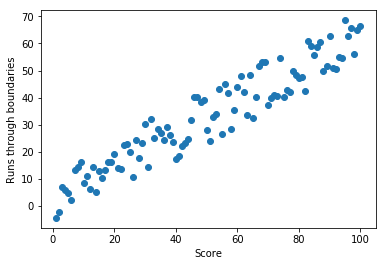

In [508]:
# Score made by a batsman vs score made through boundaries in 100 matches 

X = np.arange(1,101,1)
delta = np.random.uniform(-10,10, size=(100,))
y = .6 * X + 3 + delta
plt.scatter(X, y)
plt.xlabel('Score')
plt.ylabel('Runs through boundaries')

In [509]:
slope, intercept, r_value, p_value, stderr = linregress(X, y)
slope, intercept

(0.58654234940691985, 3.6962889636414715)

### Linear Model:

For every unit increase in x, the change in y is constant. 

Model: For every unit increase in runs (X), the score made through boundaries increase by 0.81.
y1 = 0.81218 * X + 2.13

The data produced by the above graph is not a function but a model as all the data points do not pass the regression line.

0.8956725876272259

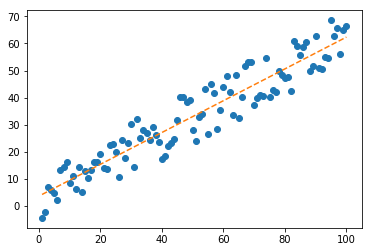

In [510]:
y1 = slope * X + intercept
plt.plot(X, y, 'o', X, y1, '--')
r_value ** 2


#### Sum of squared errors (Residual sum of squares):

    Sum of squares of difference between actual and predicted value of y.
    Finding the best fitting line.
    Discrepancy between the data and an estimation model. 
    Small RSS indicates a tight fit of the model to the data.

\begin{equation*}
\sum_{i=1}^n (y_i - \hat{y_i})^2
\end{equation*}


The line of best fit for a linear function is the line that has the lowest value of sums of squared errors among all the possible lines we could draw.

#### Root Mean Squared Error:

    Square root of the mean of sum of squared errors. 
    Measure of accuracy, to compare forecasting errors of different models for a particular data.
    Larger errors have a disproportionately large effect on RMSE

\begin{equation*}
\sqrt\frac{\sum_{i=1}^n (y_i - \hat{y_i})^2}{n}
\end{equation*}


#### Coefficient of Determination (R squared) :
Pros:

    R-square is the square of the correlation between the response values and the predicted response values.
    Percentage of variance in the dependent variable that can be explained by the predictors(x variables) together. 
    It is always between 0 and 1. 
    Higher R squared value means better correlation.

Cons:

    Every time a predictor is added to a model, the R-squared increases even though the fit may not improve.
    A model with more terms may appear to have a better fit simply because it has more terms.

#### Adjusted R Squared:

    The adjusted R-squared increases only if the new term improves the model.
    It will decrease if the new variables added to the model do not improve the fit.

\begin{equation*}
\bar{R}^2 = R^2 - \frac{k-1}{n-k}(1-R^2)
\end{equation*}

n = No of observations, k = No of parameters

### Exponential Model

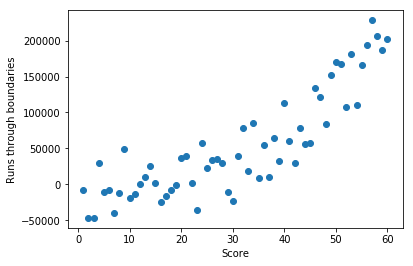

In [516]:
# A type of bacteria triples every minute. Track the growth at the end of 1 hour
X = np.arange(1,61,1)
delta = np.random.uniform(-50000,50000, size=(60,))
y = X**3 + delta
plt.scatter(X, y)
plt.xlabel('Score')
plt.ylabel('Runs through boundaries')

0.73618180221797025

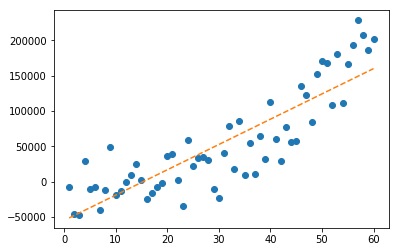

In [517]:
slope, intercept, r_value, p_value, stderr = linregress(X, y)
y1 = slope * X + intercept
plt.plot(X, y, 'o', X, y1, '--')
r_value ** 2

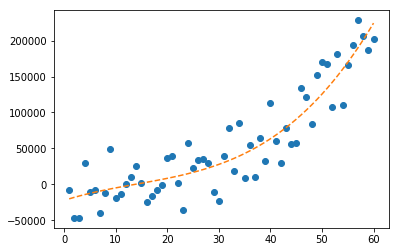

In [523]:
z = np.polyfit(X, y, 3)
f = np.poly1d(z)

y1 = f(X)

plt.plot(X, y, 'o', X, y1, '--')


### Logistic Model

In logistic growth, a population's per capita growth rate gets smaller and smaller as population size approaches a maximum imposed by limit, known as the carrying capacity.

Egs: 
The crop yield may increase by increasing value of the growth factor up to a certain level, after which it will flatten.
Pierre-François Verhulst derived logistic equation to describe the self-limiting growth of a biological population. The growth of bacteria in broth. K is the limiting value of P, the highest value that the population can reach given infinite time (or come close to reaching in finite time)

> $$F(z) = \frac{1}{1 + e^{-z}}$$


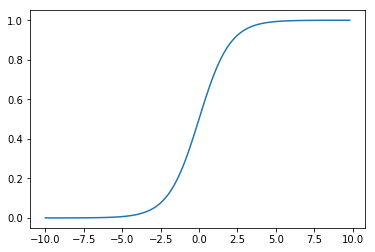

In [329]:
import math

x = np.arange(-10., 10., 0.2)
y = [1/(1+math.exp(-i)) for i in x]
plt.plot(x,y)
plt.show()

In [11]:
df = pd.DataFrame({'Cancer': [1,0,0,0,1,1,1,0,0,0,0,0,0,0,1,0,1,0,1,0], 'Smoker': [1,0,0,0,1,1,0,1,0,0,1,1,0,0,0,1,1,1,1,0]})
df.head()

,Cancer,Smoker
0,1,1
1,0,0
2,0,0
3,0,0
4,1,1


In [12]:
df = pd.crosstab(df['Cancer'],df['Smoker']).reset_index(drop = True).rename({0:'Non-Smoker', 1: 'Smoker'}).rename(columns = {0: 'No-Cancer', 1:'Cancer'})
df

Smoker,No-Cancer,Cancer
Non-Smoker,8,5
Smoker,2,5


### Odds ratio and Logistic Regression

Probability: Chance of an event occuring

Odds: Ratio of favorable outcomes to unfavorable outcomes (p/1-p)

Odds Ratio: The odds that an outcome will occur given a exposure, compared to the odds that the outcome will occur in the absence of that exposure. 

Odds of cancer in smokers (exposure) = No of people with cancer who are smokers/No of people with cancer who are smokers = 5/5

Odds of cancer in non-smokers (no exposure) = No of people with no cancer who are non- smokers/No of people with no cancer who are smokers = 8/2

Odd ratio = (5/5)/(8/2) = 5 x 2 / 8 x 5 = 1/4

The odds of cancer in people who smoke are 4 times greater than the odds of cancer in people who do not smoke.

Logit: Log to the base e of odds

Logistic regression is in reality an ordinary regression using the logit as the response variable. The logit transformation allows for a linear relationship between the response variable and the coefficients

    logit(p) = log(p/(1-p))= β0 + β1*x1 + … + βi*xi
    p= exp(β0 + β1*x1 + … + βi*xi)/(1+exp(β0 + β1*x1 + … + βi*xi))

We get a linear model but it's modeling the probabilities on a non-linear scale